# Flutuação do Vácuo

* PET Física - UFRN
* Petiano: Wallysson Pereira da Silva
* Data: 24/04/2026 

$\quad$ Nessa projeto estaremos utilizando um resultado bem interessante da Teoria Quãntica de Campos para simular o comportamento do vácuo. Como será desenvolvido mais adiante, esse resultado nos indica que o vácuo não é totalmente isento de energia, ainda há pequenas 

## Importando bibliotecas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

## Informações sobre as bibliotecas

In [ ]:
%load_ext version_information
%version_information Matplotlib, Numpy

Software versions
Python 3.13.0 64bit [MSC v.1941 64 bit (AMD64)]
IPython 8.29.0
OS Windows 11 10.0.26100 SP0
Matplotlib 3.9.2
Numpy 2.1.3
Sat Jul 26 19:17:13 2025 Hora Padrão de Buenos Aires

## Introdução Teórica

## Simulação

### m = 1.0

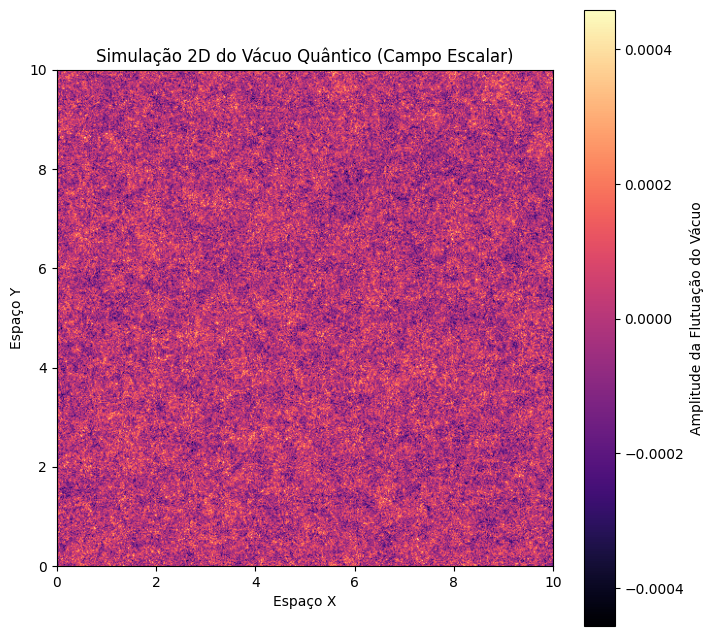

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parâmetros da Simulação ---
N = 512        # Tamanho da grade (256x256 pixels). Quanto maior, mais resolução.
L = 10.0       # Tamanho físico do nosso "pedaço de universo"
m = 1.0        # Massa da partícula do campo (evita divisão por zero)

# --- 2. Criar o Espaço dos Momentos (k) ---
# Aqui definimos as frequências (ondas) possíveis na nossa grade
kx = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
ky = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky)

# --- 3. Calcular a Energia (omega_k) ---
# A relação de dispersão: omega_k = sqrt(|k|^2 + m^2)
omega_k = np.sqrt(KX**2 + KY**2 + m**2)

# --- 4. Gerar o "Ruído Quântico" ---
# Simulamos os operadores de criação/aniquilação como números complexos aleatórios.
# Eles seguem uma distribuição normal (Gaussiana).
ruido_real = np.random.normal(0, 1, (N, N))
ruido_imag = np.random.normal(0, 1, (N, N))
a_k = (ruido_real + 1j * ruido_imag) / np.sqrt(2)

# --- 5. A Equação do Campo ---
# Modulamos o ruído pela energia: o termo 1 / sqrt(2 * omega_k) da sua imagem.
phi_k = a_k / np.sqrt(2 * omega_k)

# --- 6. Transformada Inversa de Fourier (IFFT) ---
# Pegamos as ondas no espaço dos momentos e transformamos no campo físico no espaço real.
phi_x = np.fft.ifft2(phi_k)

# O campo escalar físico é a parte real do resultado
campo_fisico = np.real(phi_x)

# --- 7. Visualização ---
plt.figure(figsize=(8, 8))
# Usamos o colormap 'magma' ou 'twilight' para dar um visual parecido com o da sua imagem
plt.imshow(campo_fisico, cmap='magma', extent=[0, L, 0, L])
plt.colorbar(label='Amplitude da Flutuação do Vácuo')
plt.title('Simulação 2D do Vácuo Quântico (Campo Escalar)')
plt.xlabel('Espaço X')
plt.ylabel('Espaço Y')
plt.show()

# m = 100.0

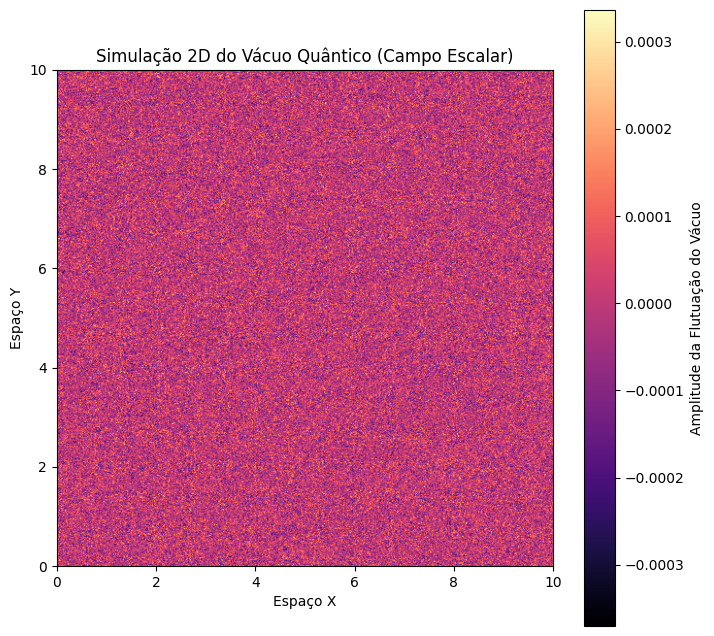

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parâmetros da Simulação ---
N = 512        # Tamanho da grade (256x256 pixels). Quanto maior, mais resolução.
L = 10.0       # Tamanho físico do nosso "pedaço de universo"
m = 100.0        # Massa da partícula do campo (evita divisão por zero)

# --- 2. Criar o Espaço dos Momentos (k) ---
# Aqui definimos as frequências (ondas) possíveis na nossa grade
kx = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
ky = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky)

# --- 3. Calcular a Energia (omega_k) ---
# A relação de dispersão: omega_k = sqrt(|k|^2 + m^2)
omega_k = np.sqrt(KX**2 + KY**2 + m**2)

# --- 4. Gerar o "Ruído Quântico" ---
# Simulamos os operadores de criação/aniquilação como números complexos aleatórios.
# Eles seguem uma distribuição normal (Gaussiana).
ruido_real = np.random.normal(0, 1, (N, N))
ruido_imag = np.random.normal(0, 1, (N, N))
a_k = (ruido_real + 1j * ruido_imag) / np.sqrt(2)

# --- 5. A Equação do Campo ---
# Modulamos o ruído pela energia: o termo 1 / sqrt(2 * omega_k) da sua imagem.
phi_k = a_k / np.sqrt(2 * omega_k)

# --- 6. Transformada Inversa de Fourier (IFFT) ---
# Pegamos as ondas no espaço dos momentos e transformamos no campo físico no espaço real.
phi_x = np.fft.ifft2(phi_k)

# O campo escalar físico é a parte real do resultado
campo_fisico = np.real(phi_x)

# --- 7. Visualização ---
plt.figure(figsize=(8, 8))
# Usamos o colormap 'magma' ou 'twilight' para dar um visual parecido com o da sua imagem
plt.imshow(campo_fisico, cmap='magma', extent=[0, L, 0, L])
plt.colorbar(label='Amplitude da Flutuação do Vácuo')
plt.title('Simulação 2D do Vácuo Quântico (Campo Escalar)')
plt.xlabel('Espaço X')
plt.ylabel('Espaço Y')
plt.show()

## Evolução Temporal

Gerando o GIF... Isso pode levar alguns segundos.
Pronto! O arquivo 'vacuo_quantico.gif' foi salvo na mesma pasta deste script.


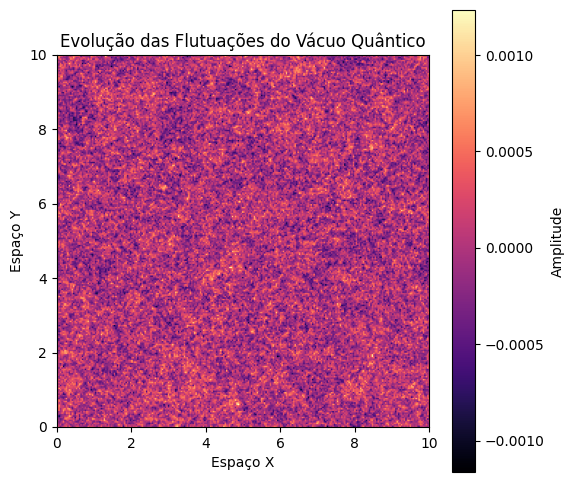

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- 1. Parâmetros da Simulação ---
N = 256        # Resolução da grade (reduzida para 128x128 para o GIF gerar mais rápido)
L = 10.0       # Tamanho físico da grade
m = 1.0        # Massa da partícula (evita divisões por zero e controla o tamanho das flutuações)
frames = 60    # Número de quadros da animação
dt = 0.1       # Tamanho do passo de tempo entre os quadros

# --- 2. Criar o Espaço dos Momentos (k) e a Energia (omega_k) ---
kx = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
ky = np.fft.fftfreq(N, d=L/N) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky)

omega_k = np.sqrt(KX**2 + KY**2 + m**2)

# --- 3. Gerar as Condições Iniciais do Vácuo (Fixo) ---
# Geramos as amplitudes complexas aleatórias UMA VEZ. 
# Estas são as "sementes" quânticas que vão evoluir no tempo.
ruido_real = np.random.normal(0, 1, (N, N))
ruido_imag = np.random.normal(0, 1, (N, N))
a_k = (ruido_real + 1j * ruido_imag) / np.sqrt(2)

# Modulamos pela energia (o termo 1 / sqrt(2 * omega_k))
phi_k_inicial = a_k / np.sqrt(2 * omega_k)

# --- 4. Preparar a Animação ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title("Evolução das Flutuações do Vácuo Quântico")
ax.set_xlabel("Espaço X")
ax.set_ylabel("Espaço Y")

# Geramos o primeiro quadro no tempo t=0 para inicializar a imagem
campo_t0 = np.real(np.fft.ifft2(phi_k_inicial))
im = ax.imshow(campo_t0, cmap='magma', extent=[0, L, 0, L], animated=True)
fig.colorbar(im, ax=ax, label='Amplitude')


# --- 5. Função de Atualização (O motor do tempo) ---
def update(frame):
    t = frame * dt
    
    # A MÁGICA DO TEMPO: Multiplicamos a amplitude inicial pela fase e^{-i * omega_k * t}
    fase_temporal = np.exp(-1j * omega_k * t)
    phi_k_t = phi_k_inicial * fase_temporal
    
    # Transformada inversa para voltar ao espaço real
    campo_fisico_t = np.real(np.fft.ifft2(phi_k_t))
    
    # Atualiza os dados da imagem
    im.set_array(campo_fisico_t)
    
    # Mantém o contraste dinâmico ajustado
    im.set_clim(vmin=np.min(campo_fisico_t), vmax=np.max(campo_fisico_t))
    return [im]

# --- 6. Gerar e Salvar o GIF ---
print("Gerando o GIF... Isso pode levar alguns segundos.")
ani = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

# Salva o arquivo. O 'pillow' é um ótimo escritor nativo de GIFs no Python.
ani.save('vacuo_quantico.gif', writer='pillow', fps=15)
print("Pronto! O arquivo 'vacuo_quantico.gif' foi salvo na mesma pasta deste script.")